# 02 · Monte Carlo estimation and its error

A Monte Carlo estimate is a sample mean, so its error is governed by the law of large numbers and the central
limit theorem: it shrinks like σ/√n whatever the dimension. This notebook makes that statement operational -
standard errors, confidence intervals and their actual coverage, the sample size for a required precision,
integration in many dimensions where grids fail - and shows where it breaks: rare events, heavy tails and
skewed outputs.

**What you will learn**
- write a Monte Carlo estimate with its standard error and confidence interval
- check the coverage of an interval procedure by simulation
- choose the sample size for a target precision
- explain why rare events and heavy tails break crude Monte Carlo

**Before you start:** notebooks 00-01; the central limit theorem  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from engstoch import montecarlo as mc, output as oa, special as sf
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## The estimator and its standard error

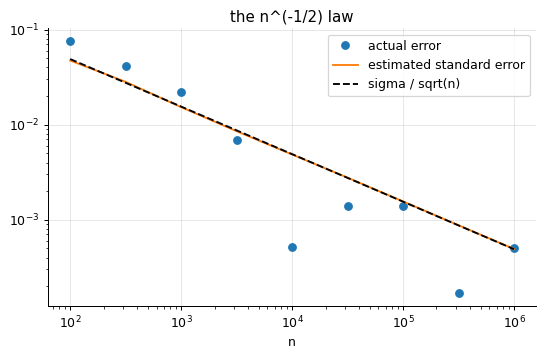

n = 10000: estimate 1.71742 +- 0.00492, 95 % CI (1.70778, 1.72706), truth 1.71828


In [2]:
h = lambda u: np.exp(u)                      # E[e^U] = e - 1
truth = np.e - 1
ns = np.logspace(2, 6, 9).astype(int)
errs = [abs(mc.mean_ci(h(R(int(n)).random(n)))["estimate"] - truth) for n in ns]
ses = [mc.mean_ci(h(R(int(n)).random(n)))["std_error"] for n in ns]
plt.loglog(ns, errs, "o", label="actual error"); plt.loglog(ns, ses, "-", label="estimated standard error"); plt.loglog(ns, 0.49 / np.sqrt(ns), "k--", label="sigma / sqrt(n)")
plt.xlabel("n"); plt.legend(); plt.title("the n^(-1/2) law"); plt.show()
r = mc.mean_ci(h(R(0).random(10_000)))
print(f"n = 10000: estimate {r['estimate']:.5f} +- {r['std_error']:.5f}, 95 % CI ({r['ci'][0]:.5f}, {r['ci'][1]:.5f}), truth {truth:.5f}")

The estimator's standard deviation is σ/√n, and σ is estimated from the same sample. Gaining one decimal digit
costs a hundredfold more samples - the price of Monte Carlo's generality, which notebooks 03 and 04 try to
lower.

## Do the intervals cover?

In [3]:
rows = []
for name, sampler, truth_ in (("uniform, n = 20", lambda r: r.random(20), 0.5), ("exponential, n = 10", lambda r: r.exponential(size=10), 1.0),
                              ("exponential, n = 100", lambda r: r.exponential(size=100), 1.0), ("lognormal(0, 1.5), n = 100", lambda r: r.lognormal(0, 1.5, 100), np.exp(1.125)),
                              ("lognormal(0, 1.5), n = 10000", lambda r: r.lognormal(0, 1.5, 10_000), np.exp(1.125))):
    cis = [mc.mean_ci(sampler(R(100 + k)), method="t")["ci"] for k in range(2000)]
    c = oa.coverage([a for a, b in cis], [b for a, b in cis], truth_)
    rows.append((name, c["coverage"], c["std_error"]))
print(pd.DataFrame(rows, columns=["output", "coverage of nominal 95 % t intervals", "+-"]).to_string(index=False, float_format="%.3f"))

                      output  coverage of nominal 95 % t intervals    +-
             uniform, n = 20                                 0.943 0.005
         exponential, n = 10                                 0.905 0.007
        exponential, n = 100                                 0.940 0.005
  lognormal(0, 1.5), n = 100                                 0.846 0.008
lognormal(0, 1.5), n = 10000                                 0.938 0.005


The interval is only asymptotically right. For symmetric outputs it is accurate at n = 20; for skewed outputs
it undercovers, and a heavy right tail (a lognormal with σ = 1.5, much like insurance losses or repair costs)
drags coverage down to about 85 % at n = 100 and keeps it slightly below nominal even at n = 10⁴: the sample
rarely contains the large values that carry the mean, so both the mean and its standard error are
underestimated together. Checking coverage by simulation, as here,
is the honest test of any interval procedure.

## How many samples?

In [4]:
pilot = h(R(1).random(500))
sigma = pilot.std(ddof=1)
for hw in (1e-2, 1e-3, 1e-4):
    print(f"half-width {hw:g} at 95 %: n = {mc.sample_size(sigma, hw):,}")
r = mc.two_stage(lambda n: h(R(2).random(n)), 1e-3)
print(f"\ntwo-stage procedure: pilot sigma {r['pilot_std']:.4f} -> n = {r['n']:,}, achieved half-width {(r['ci'][1] - r['ci'][0]) / 2:.2e}")

half-width 0.01 at 95 %: n = 9,180
half-width 0.001 at 95 %: n = 917,978
half-width 0.0001 at 95 %: n = 91,797,771

two-stage procedure: pilot sigma 0.4934 -> n = 935,120, achieved half-width 9.97e-04


With a pilot estimate of σ, n = (zσ/h)² gives a target half-width h; the two-stage procedure runs the pilot,
computes n and finishes the job. The pilot's own error in σ makes the final half-width random - a few percent
off here.

## Rare events

In [5]:
rows = []
for a in (1, 2, 3, 4, 5):
    p = 1 - sf.norm_cdf(a)
    n = 100_000
    k = int(np.sum(R(a).standard_normal(n) > a))
    r = mc.proportion_ci(k, n)
    rows.append((a, p, r["estimate"], mc.relative_error(r) if k else np.inf, r["ci"][1], np.sqrt((1 - p) / (n * p))))
print(pd.DataFrame(rows, columns=["a", "P(Z > a)", "estimate (n = 1e5)", "relative error", "Wilson upper limit", "theory sqrt((1-p)/(np))"]).to_string(index=False, float_format="%.3g"))

 a  P(Z > a)  estimate (n = 1e5)  relative error  Wilson upper limit  theory sqrt((1-p)/(np))
 1     0.159               0.156         0.00736               0.158                  0.00728
 2    0.0228              0.0225          0.0209              0.0234                   0.0207
 3   0.00135             0.00136          0.0857             0.00161                    0.086
 4  3.17e-05               1e-05               1            5.66e-05                    0.562
 5  2.87e-07                   0             inf            3.84e-05                     5.91


For a probability p the relative error of crude Monte Carlo is √((1 − p)/(np)): to get 10 % accuracy one needs
about 100/p samples - 10⁸ for p = 10⁻⁶. Beyond a = 4 the estimate is zero; the Wilson interval still gives an
honest upper limit (the Wald interval would claim certainty). Importance sampling (notebook 03) fixes this.

## Integration where grids fail

In [6]:
rows = []
for d in (1, 2, 5, 10, 20):
    f = lambda x: np.exp(-np.sum(x, axis=1) / d)
    exact = (d * (1 - np.exp(-1 / d))) ** d
    r = mc.integrate(f, np.zeros(d), np.ones(d), 100_000, R(d))
    m = int(round(100_000 ** (1 / d)))
    g1 = (np.arange(m) + 0.5) / m
    grid_est = (np.mean(np.exp(-g1 / d))) ** d                         # midpoint product rule with m^d points (separable f)
    rows.append((d, exact, abs(r["estimate"] - exact), r["std_error"], m, abs(grid_est - exact)))
print(pd.DataFrame(rows, columns=["d", "exact", "MC error (1e5 points)", "MC std error", "grid points per axis", "midpoint-grid error (same budget)"]).to_string(index=False, float_format="%.2e"))

 d    exact  MC error (1e5 points)  MC std error  grid points per axis  midpoint-grid error (same budget)
 1 6.32e-01               2.79e-05      5.73e-04                100000                           2.63e-12
 2 6.19e-01               1.26e-04      4.02e-04                   316                           1.29e-07
 5 6.12e-01               8.62e-05      2.51e-04                    10                           5.10e-05
10 6.09e-01               4.84e-05      1.77e-04                     3                           2.82e-04
20 6.08e-01               2.87e-04      1.24e-04                     2                           3.16e-04


With a budget of 10⁵ points a product grid has 10⁵⁄ᵈ points per axis - three per axis in ten dimensions, two in
twenty - and its O(m⁻²) accuracy per axis is gone: from d = 10 on it is no better than Monte Carlo, whose error
is the same σ/√n in every dimension. (This integrand is separable and very smooth, which flatters the grid; a
general grid rule would lose much earlier.) Dimension-independence is why Monte
Carlo dominates in finance, physics and reliability.

## Inside the algorithm: Welford's one-pass variance

In [7]:
x = h(R(11).random(100_000)) + 1e9          # a large offset ruins the naive formula
n, mean, m2 = 0, 0.0, 0.0
for v in x[:20_000]:
    n += 1; d = v - mean; mean += d / n; m2 += d * (v - mean)
naive = (np.sum(x[:20_000] ** 2) - 20_000 * np.mean(x[:20_000]) ** 2) / 19_999
print(f"Welford variance {m2 / (n - 1):.6f}, two-pass {np.var(x[:20_000], ddof=1):.6f}, naive sum-of-squares {naive:.1f}")

Welford variance 0.241446, two-pass 0.241446, naive sum-of-squares 209.7


## Exercises
1. Estimate pi by throwing points in the unit square, with a 99 % interval, and find the number of points needed for six correct digits. How long would that take at 10^8 points per second?
2. For the lognormal(0, 1.5) mean, compare the coverage at n = 1000 of the t interval and of a percentile bootstrap interval (2000 resamples) over 500 replications. Does the bootstrap fix the problem?
3. **Implement it yourself:** write the Wilson score interval for a proportion and use it to show by simulation that, for p = 0.001 and n = 2000, the Wald interval's coverage is far below 95 % while Wilson's is close.